In [27]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from load_data import load_dataset
from analysis import basic_info, unique_values, missing_values
from transform import remove_outliers

# Configuración visual
sns.set(style="whitegrid")

# Análisis Descriptivo del Dataset

In [8]:
df = load_dataset("../data/avocado.csv")
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [9]:
basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None
         Unnamed: 0  AveragePrice  Total Volume          4046          4225  \
count  18249.000000  18249.000000  1.824900e+04  1.824900

In [10]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [11]:
unique_values(df)

{'Unnamed: 0': 53,
 'Date': 169,
 'AveragePrice': 259,
 'Total Volume': 18237,
 '4046': 17702,
 '4225': 18103,
 '4770': 12071,
 'Total Bags': 18097,
 'Small Bags': 17321,
 'Large Bags': 15082,
 'XLarge Bags': 5588,
 'type': 2,
 'year': 4,
 'region': 54}

In [12]:
missing_values(df)

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Unnamed: 0', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'year'],
      dtype='object')


En la gráfica de distribución de la variable AveragePrice se observa que los precios no siguen una distribución completamente uniforme. La mayoría de los valores se concentran en un rango medio (aproximadamente entre 1 y 2), lo que indica que los precios más comunes del aguacate se encuentran en ese intervalo.
También se puede notar una ligera asimetría hacia la derecha, lo que sugiere que existen algunos precios más altos, pero son menos frecuentes.

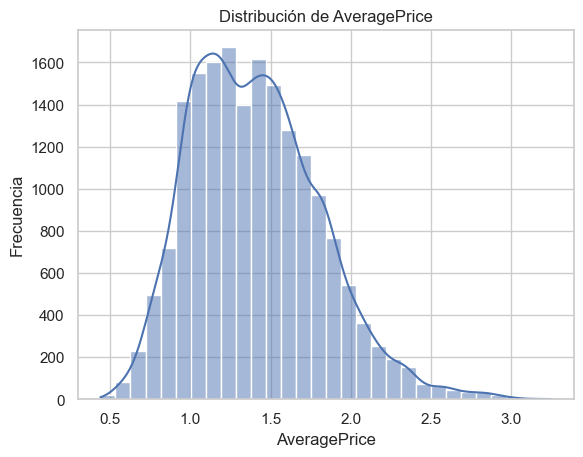

In [18]:
numeric_cols = ['AveragePrice']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

La distribución de Total Volume presenta una fuerte asimetría positiva (sesgo a la derecha), donde la mayoría de los registros tienen volúmenes bajos, pero existen algunos valores extremadamente altos.
Esto indica que en ciertos periodos o regiones se manejan cantidades mucho mayores de aguacates, lo cual puede representar mercados grandes o picos de producción.

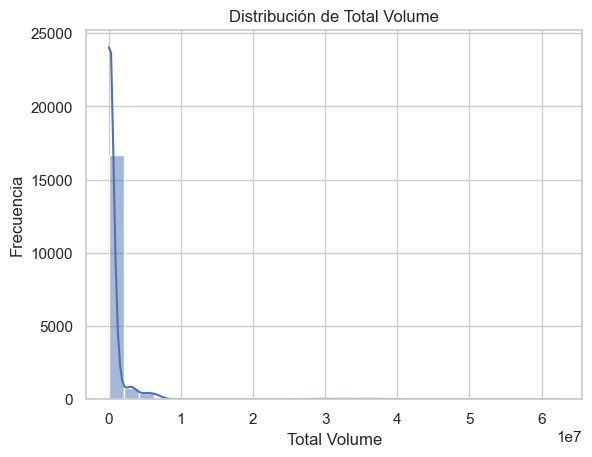

In [19]:
numeric_cols = ['Total Volume']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Las variables correspondientes a los diferentes tipos de aguacate muestran distribuciones altamente sesgadas hacia la derecha. Esto indica que la mayoría de las ventas son bajas en estas categorías, pero existen algunos casos donde las cantidades son considerablemente altas.
Esto puede sugerir que ciertos tipos de aguacate dominan el mercado en momentos específicos.

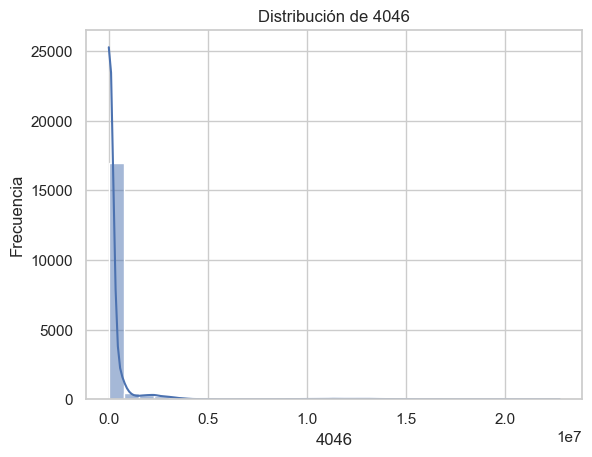

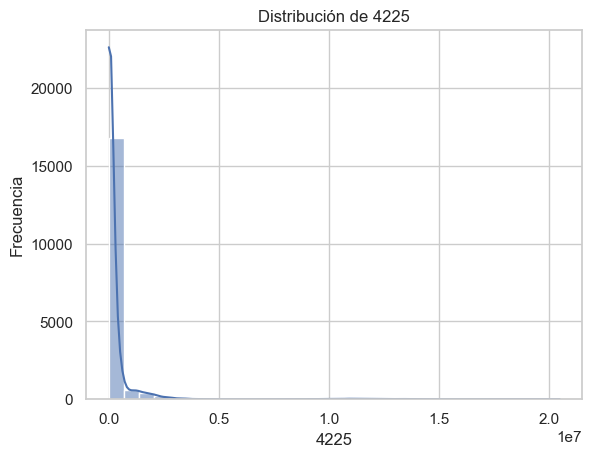

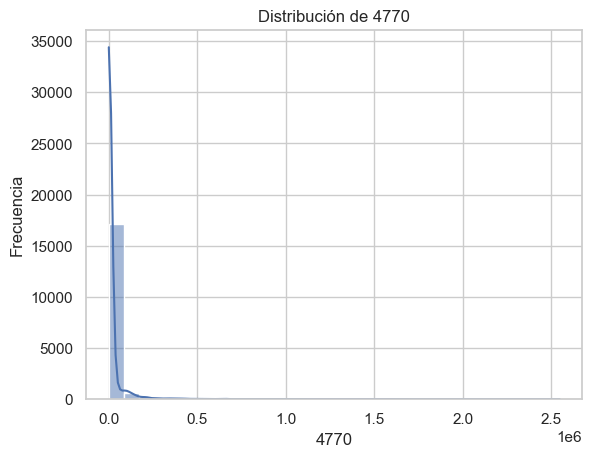

In [20]:
numeric_cols = ['4046', '4225', '4770']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

- Total Bags y Small Bags: 
Muestran distribuciones muy similares y sesgadas a la derecha, lo que indica que los aguacates en bolsa pequeña dominan este segmento. La mediana de Total Bags (~39,700) y de Small Bags (~26,000) están muy por debajo de sus medias respectivas, confirmando la presencia de mercados con volúmenes muy elevados.

- Large Bags: 
También sesgada, con el 50% de observaciones por debajo de ~2,600 unidades, mucho menor que Small Bags, lo que sugiere que las bolsas grandes son menos populares.

- XLarge Bags: 
El 75% de los registros tienen volumen 0, lo que indica que prácticamente este formato no se comercializa en la mayoría de regiones/períodos.

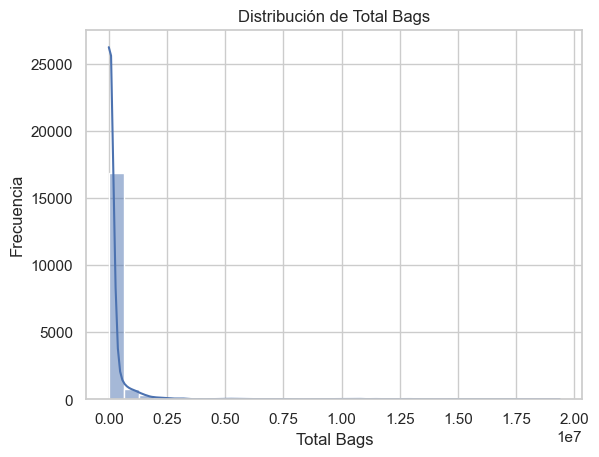

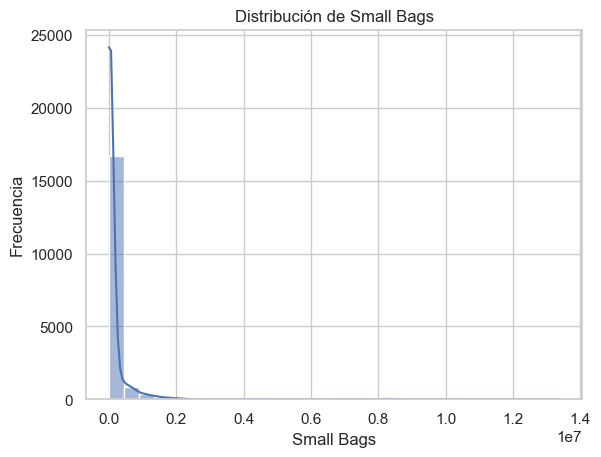

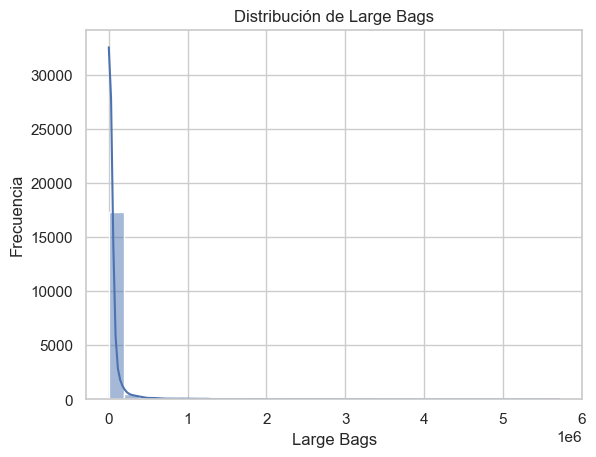

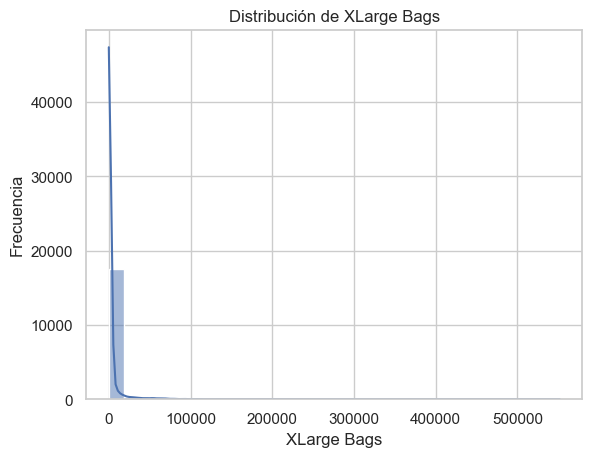

In [22]:
numeric_cols = ['Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

En el boxplot de AveragePrice se puede observar una distribución relativamente compacta con la caja concentrada entre $1.10 y $1.66. La mediana ($1.37) está ligeramente desplazada hacia el extremo inferior de la caja, lo que indica un sesgo positivo moderado. Sin embargo, el aspecto más relevante son los outliers superiores: todos los registros con precio por encima de $2.50 son considerados atípicos. El máximo registrado ($3.25) supera casi en 1 dólar esta frontera, lo que sugiere que esos precios corresponden principalmente a aguacates orgánicos en mercados premium o períodos de escasez estacional. No se observan outliers inferiores, ya que el mínimo ($0.44) se encuentra por encima del fence inferior calculado ($0.26).

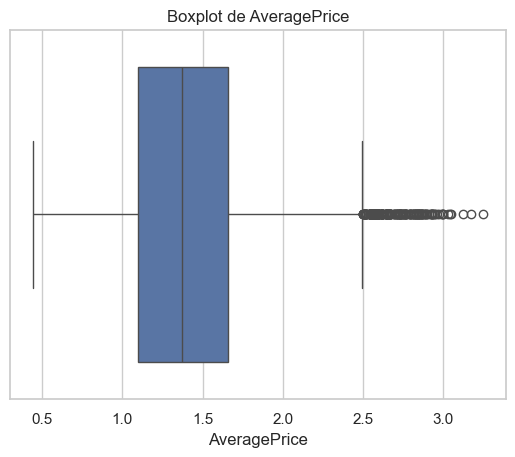

In [23]:
numeric_cols = ['AveragePrice']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

La caja es extremadamente estrecha en relación al rango total de los datos. La mediana (~107,000) cae bastante por debajo del centro de la caja, evidenciando fuerte asimetría. Lo más notable es que el máximo observado (~62.5 millones) supera en casi 60 veces el fence superior (~1.07 millones), lo que significa que una gran cantidad de registros son outliers. Estos valores extremos corresponden a la región TotalUS (total nacional) que agrega el volumen de todos los mercados, lo que infla artificialmente los datos. En la práctica, la mayoría de los mercados regionales operan en rangos mucho menores.

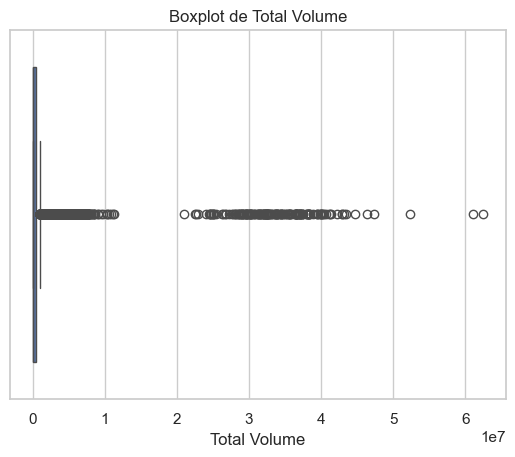

In [24]:
numeric_cols = ['Total Volume']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

- El boxplot de la variable 4046 muestra una caja considerablemente amplia (de 854 a 111,020), reflejando alta variabilidad en las ventas de aguacates pequeños entre regiones. La mediana (~8,600) está muy próxima al Q1, indicando que más de la mitad de los mercados vende menos de 9,000 unidades de este tipo. Los outliers son numerosos y extremos: el valor máximo (~22.7 millones) está más de 80 veces por encima del fence superior

- El boxplot de 4225 muestra la caja más amplia de los tres tipos PLU, lo que refleja que el aguacate grande (Hass grande) presenta la mayor variabilidad relativa entre mercados. La mediana (~29,000) se ubica muy próxima al Q1 (~3,000), lo que indica alta concentración en volúmenes bajos. El fence superior (~370,000) es superado ampliamente por el máximo (~20.5 millones), confirmando que este tipo domina el volumen en los mercados más grandes. Dado que 4225 tiene el promedio más alto de los tres PLU (~295,000), es el aguacate de mayor volumen de ventas a nivel general.

- El boxplot de 4770 es el más revelador en cuanto a distribución extrema. El Q1 es exactamente 0, lo que significa que al menos el 25% de todos los registros no registran ninguna venta de aguacate extra grande. La mediana es de apenas ~185 unidades, casi marginal. Sin embargo, el máximo (~2.5 millones) supera en más de 163 veces el fence superior, con outliers que corresponden a los mercados de mayor tamaño. Esto evidencia que el 4770 es un producto de nicho, apenas comercializado en la mayoría de regiones, pero con picos masivos en mercados específicos.

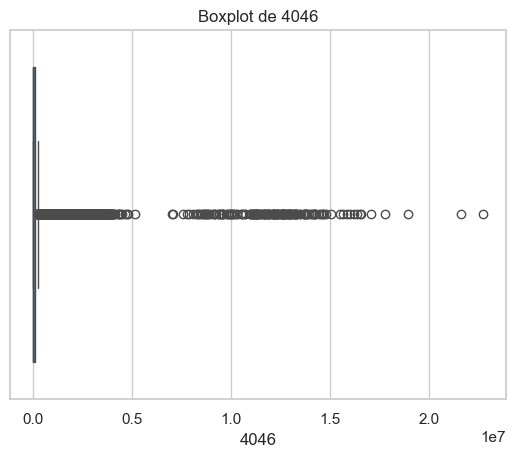

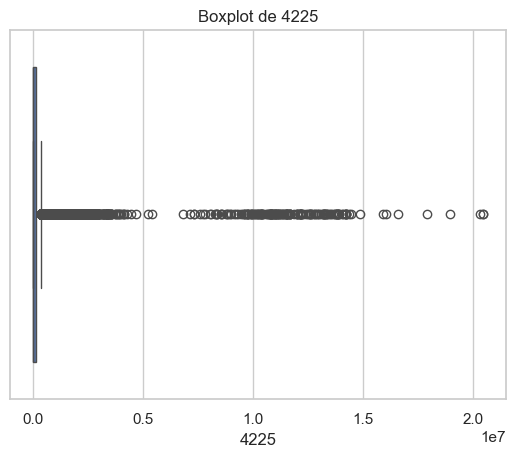

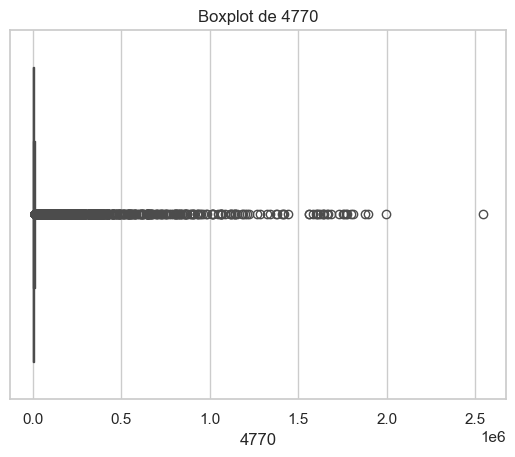

In [ ]:
numeric_cols = ['4046', '4225', '4770']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Todos los boxplots de bolsas presentan el mismo patrón: cajas compactas con colas superiores extremadamente largas y abundantes outliers. Destaca que:

- XLarge Bags: El Q1 y la mediana son ambos 0, lo que indica que más del 50% de los registros no tienen ventas de bolsas extra grandes. Los escasos outliers (máx. ~551,000) corresponden a mercados muy específicos.

- Small Bags domina el segmento de bolsas, con los mayores volúmenes y la caja más amplia.

- Large Bags tiene una distribución intermedia pero igualmente sesgada.

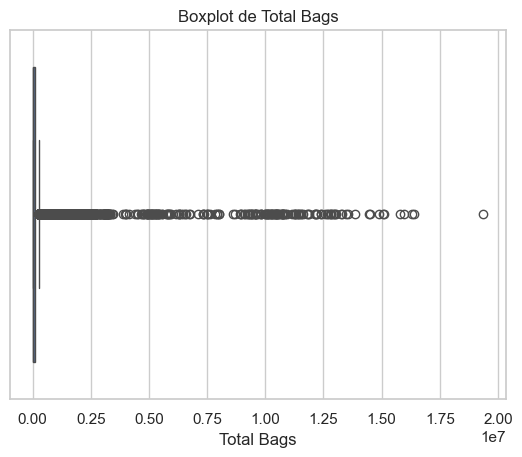

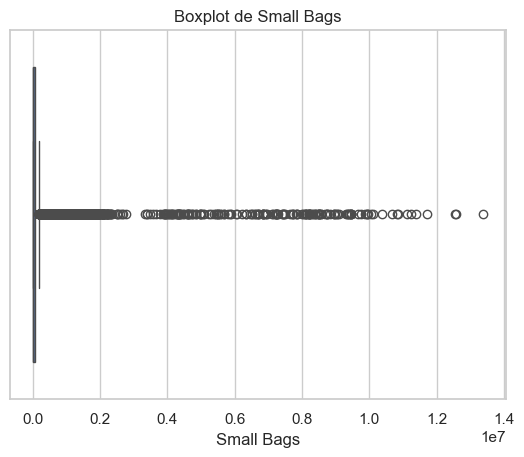

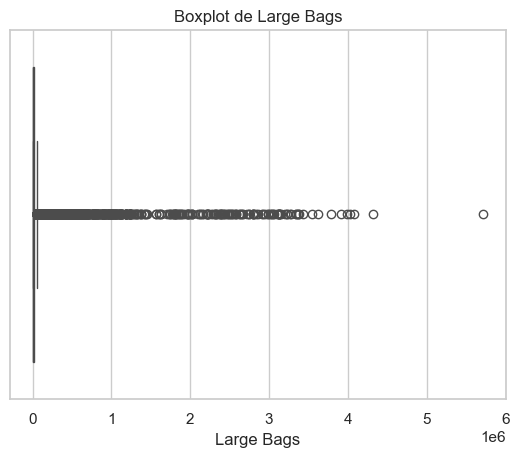

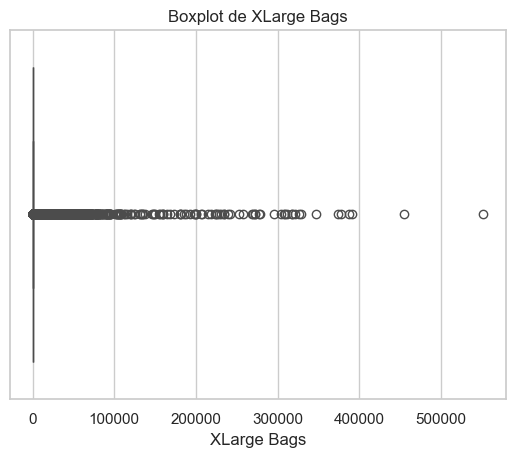

In [34]:
numeric_cols = ['Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

1. Alta correlación entre variables de volumen:
- Se observa una correlación muy alta (cercana a 1) entre Total Volume y variables como 4046, 4225 y 4770. Esto indica que el volumen total está directamente relacionado con la cantidad de aguacates vendidos por tipo.

- Asimismo, variables como Total Bags, Small Bags, Large Bags y XLarge Bags también presentan correlaciones muy altas entre sí (por ejemplo, Total Bags con Small Bags ≈ 0.99). Esto sugiere que estas variables contienen información muy similar o redundante.

- La alta correlación entre múltiples variables de volumen evidencia un problema de multicolinealidad, ya que varias variables están altamente relacionadas entre sí. Esto puede afectar negativamente algunos modelos predictivos, especialmente los modelos lineales.

2. Relación del precio con otras variables
- La variable AveragePrice presenta correlaciones negativas leves con la mayoría de las variables de volumen (entre -0.12 y -0.21 aproximadamente). Esto indica que, en general, cuando el volumen de aguacates aumenta, el precio tiende a disminuir ligeramente.
- Más oferta → menor precio (ley básica de mercado)
- Sin embargo, estas correlaciones no son muy fuertes, lo que sugiere que el precio no depende únicamente del volumen, sino de otros factores adicionales.

3. Variables con baja relación
Variables como year muestran una correlación muy baja con la mayoría de las variables, lo que indica que el año por sí solo no explica cambios significativos en el precio o volumen dentro del dataset.

5. Variable irrelevante
La variable Unnamed: 0 no presenta correlaciones significativas con las demás variables, lo que sugiere que no aporta información útil al análisis y podría ser eliminada.

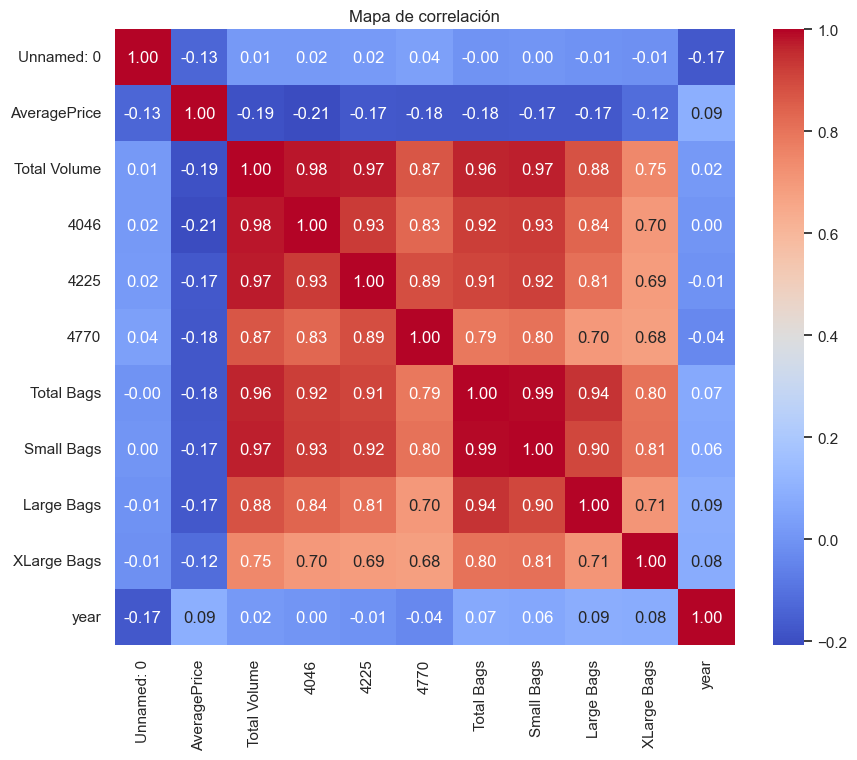

In [42]:
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de correlación")
plt.show()

Este boxplot compara directamente la distribución del precio entre aguacates convencionales y orgánicos:

- Aguacates convencionales: La caja se concentra entre ~$0.90 y ~$1.50, con mediana alrededor de $1.15. Los outliers superiores alcanzan hasta ~$2.50, pero son pocos.

- Aguacates orgánicos: La caja se ubica entre ~$1.30 y ~$2.00, con mediana cercana a $1.65. Los outliers superiores llegan hasta ~$3.25.

La diferencia entre medianas es de aproximadamente $0.50, lo que equivale a un precio ~43% más alto para los orgánicos respecto a los convencionales. Esta brecha confirma que el tipo de aguacate es una variable predictora clave para el precio. Los orgánicos no solo son más caros en promedio, sino que también presentan mayor variabilidad de precios, reflejando una demanda más heterogénea. El solapamiento parcial de las cajas indica que en ciertos mercados o temporadas, los precios convencionales pueden acercarse a los orgánicos.

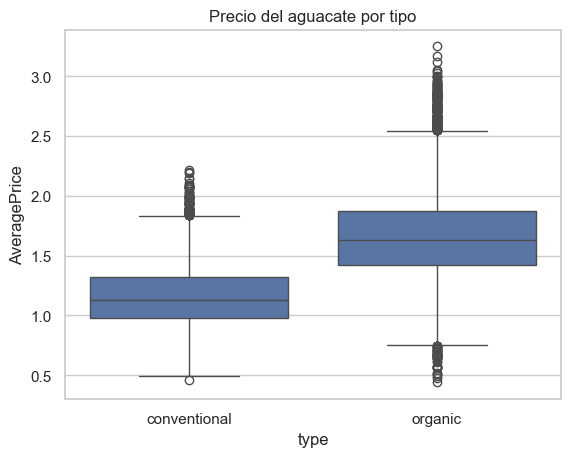

In [43]:
plt.figure()

sns.boxplot(x="type", y="AveragePrice", data=df)

plt.title("Precio del aguacate por tipo")
plt.show()

La gráfica de barras del precio promedio agrupado por región revela una alta disparidad geográfica en los precios del aguacate:

- Las regiones más caras tienden a ser mercados urbanos de alto poder adquisitivo: San Francisco, Hartford/Springfield, y el Noreste en general, donde los precios promedian por encima de $1.60.

- Las regiones más baratas suelen ser mercados del interior o del sur del país como West Texas/New Mexico o Phoenix/Tucson, con promedios por debajo de $1.20.

- La diferencia entre la región más cara y la más barata puede superar los $0.60–$0.70, lo que representa una variación de más del 50% en el precio.

- La región TotalUS (promedio nacional) se ubica en el rango medio-bajo, lo que confirma que los mercados grandes y baratos arraigan el promedio nacional.

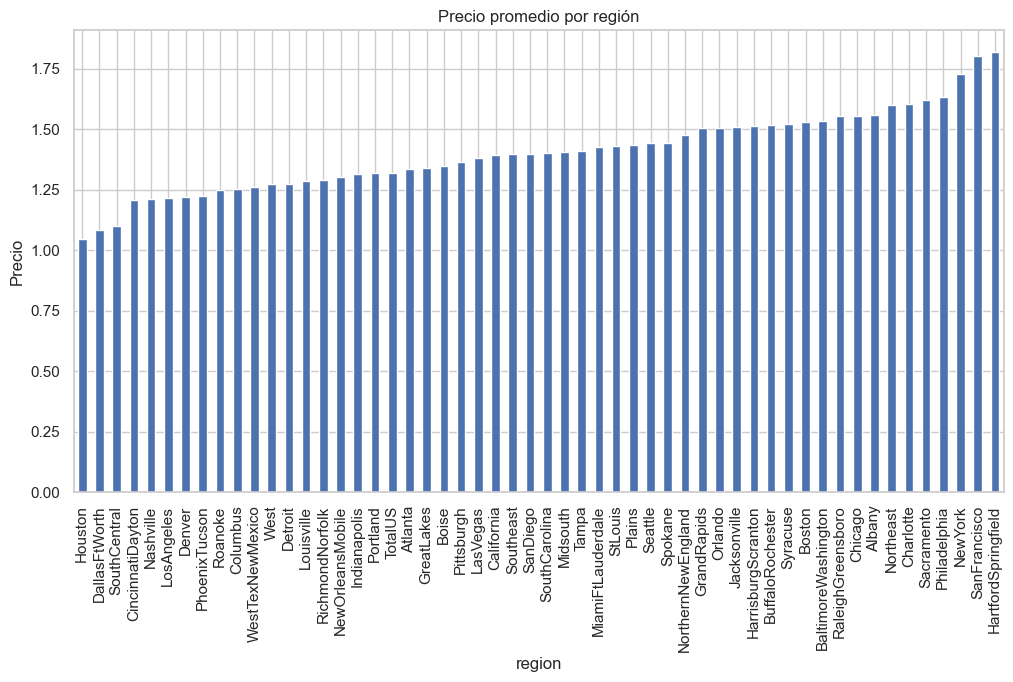

In [44]:
plt.figure(figsize=(12,6))

df.groupby("region")["AveragePrice"].mean().sort_values().plot(kind="bar")

plt.title("Precio promedio por región")
plt.ylabel("Precio")
plt.show()

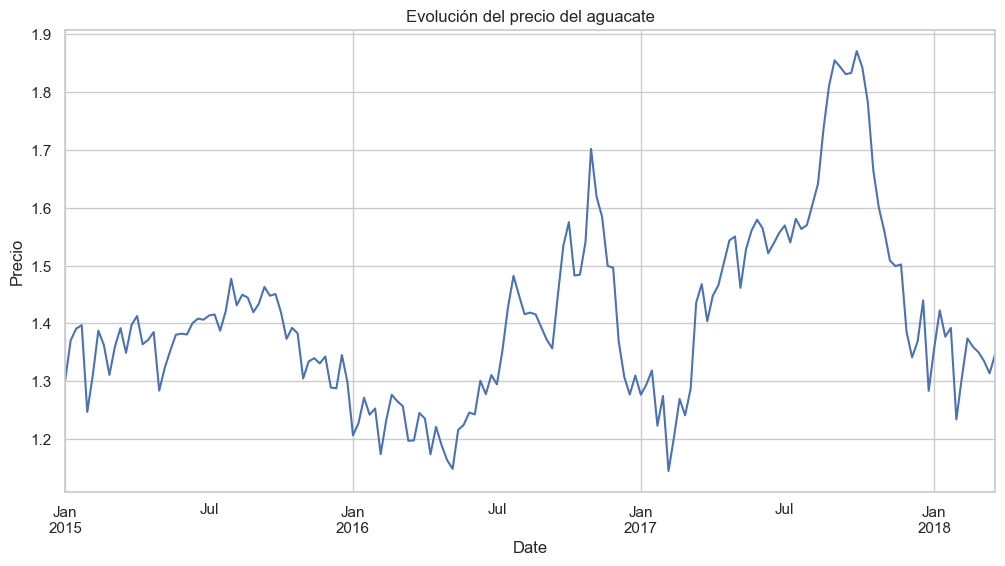

In [45]:
df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(12,6))

df.groupby("Date")["AveragePrice"].mean().plot()

plt.title("Evolución del precio del aguacate")
plt.ylabel("Precio")
plt.show()

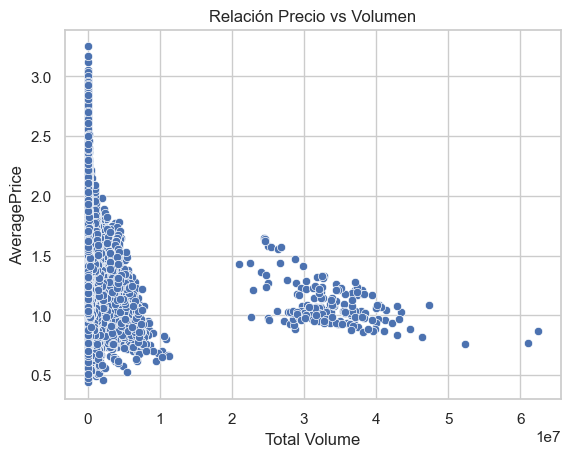

In [46]:
plt.figure()

sns.scatterplot(x="Total Volume", y="AveragePrice", data=df)

plt.title("Relación Precio vs Volumen")
plt.show()

# Limpieza y Normalización de Datos

# ANÁLISIS DE GRÁFICOS

### 1. Distribución de AveragePrice
**Interpretación:**
La distribución tiene forma asimétrica positiva (sesgo a la derecha). La mayoría de los precios se concentran entre 1.0 y 1.6. Existen valores más altos (hasta ~3.0), pero son menos frecuentes.

**Insight:**
El precio del aguacate no sigue una distribución normal perfecta, ya que presenta una cola hacia valores altos. Esto indica que existen casos donde el precio se incrementa significativamente, posiblemente por factores como escasez o demanda elevada.

### 2. Boxplot de AveragePrice (Outliers)
**Interpretación:**
La mediana está aproximadamente en ~1.3 – 1.4. Se observan muchos valores atípicos (outliers) hacia la derecha, mientras que hay pocos outliers bajos.

**Insight:**
Se identifican numerosos valores atípicos en precios altos, lo que sugiere la existencia de situaciones excepcionales en el mercado (por ejemplo, precios elevados en ciertas regiones o periodos). Estos valores pueden afectar modelos predictivos si no se tratan adecuadamente.

### 3. Mapa de correlación
**Interpretación clave:**
* **Relación con AveragePrice:** Correlaciones negativas (débiles) con Total Volume (~ -0.19), códigos 4046, 4225, 4770 y Total Bags. Es decir: A mayor volumen, menor precio (ligeramente).
* **Relación entre variables de volumen:** Correlaciones muy altas entre Total Volume con 4046, 4225 y Total Bags (> 0.95), lo que indica multicolinealidad fuerte.

**Insight:**
Existe una relación inversa entre el volumen de aguacates vendidos y su precio, lo cual es consistente con la ley de oferta y demanda. Además, se detecta una alta correlación entre variables de volumen, lo que indica redundancia de información y posible multicolinealidad.

### 4. Scatter Plot (Precio vs Volumen)
**Interpretación:**
Se observa una tendencia negativa: cuando el volumen aumenta, el precio tiende a bajar. Hay dos zonas claras: volumen bajo con precios muy variables y volumen alto con precios más estables y bajos.

**Insight:**
El precio del aguacate disminuye a medida que aumenta el volumen disponible en el mercado. Además, en volúmenes bajos se observa mayor volatilidad en los precios, lo que sugiere menor estabilidad en condiciones de baja oferta.

---

# CONCLUSIONES GENERALES

### Conclusiones del análisis exploratorio
* El precio del aguacate presenta una distribución sesgada hacia la derecha, indicando la presencia de valores altos poco frecuentes.
* Se identificaron múltiples valores atípicos en el precio, especialmente en valores altos, lo que podría afectar modelos de predicción si no se tratan adecuadamente.
* Existe una relación inversa entre el volumen de ventas y el precio, lo cual es consistente con principios económicos de oferta y demanda.
* Se detectó una alta correlación entre variables relacionadas con el volumen, lo que sugiere redundancia y posible multicolinealidad en el dataset.
* El precio presenta mayor variabilidad cuando el volumen es bajo, indicando mayor incertidumbre en escenarios de baja oferta.

### Pasos a seguir
* Eliminar la columna Unnamed: 0 por no aportar valor.
* Convertir la variable Date a formato datetime.
* Tratar los valores atípicos en AveragePrice.
* Aplicar técnicas de normalización debido a la diferencia de escalas.
* Reducir variables altamente correlacionadas para evitar multicolinealidad.

In [47]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Limpieza y Normalización de Datos

### 1. Eliminación de columnas irrelevantes
Se eliminó la columna Unnamed: 0 debido a que no aporta valor analítico y correspondía a un índice redundante.

### 2. Conversión de variables
La variable Date fue convertida a tipo datetime para facilitar el análisis temporal y posteriormente descompuesta en variables de mes (month) y día (day).

### 3. Manejo de valores nulos
No se encontraron valores nulos en el dataset; por lo tanto, no fue necesario aplicar técnicas de imputación.

### 4. Tratamiento de valores atípicos
Se utilizó el método del rango intercuartílico (IQR) debido a la alta distribucion de outliers, para detectar y eliminar valores atípicos en la variable AveragePrice, reduciendo el impacto de valores extremos en el modelo.

### 5. Transformación de variables categóricas
Las variables categóricas (type y region) fueron transformadas mediante codificación one-hot, generando variables dummy.

### 6. Conversión de variables booleanas
Las variables dummy resultantes de la categorización fueron convertidas a valores numéricos (0 y 1) para garantizar la compatibilidad con algoritmos de aprendizaje automático.

### 7. Normalización de datos
Se aplicó estandarización a las variables numéricas utilizando StandardScaler. Esto asegura que todas las variables tengan media 0 y desviación estándar 1, evitando que las diferencias de escala afecten el desempeño del modelo.

### 8. Reducción de multicolinealidad
Se identificaron variables altamente correlacionadas (como Total Volume y Total Bags). Se elimininarion de algunas de estas variables para mejorar la estabilidad y el rendimiento de modelos lineales.

---

# ANÁLISIS DEL DATASET FINAL

### 1. Dimensionalidad
* **Filas:** 18,249
* **Columnas:** 66
El número de variables aumentó considerablemente debido a la creación de variables dummy, permitiendo su uso en modelos de machine learning.

### 2. Transformaciones aplicadas
* **Variables numéricas:** Todas están estandarizadas (StandardScaler), lo que se refleja en valores cercanos a la media 0 y desviación estándar 1.
* **Variables categóricas:** Se aplicó codificación one-hot para representar regiones y tipos sin introducir un orden artificial.
* **Variables temporales:** La creación de las columnas month y day permite capturar patrones estacionales en el mercado del aguacate.

### 3. Consideraciones técnicas
Para garantizar la compatibilidad con todos los algoritmos de Scikit-Learn, se realizó la conversión de tipos de datos booleanos a enteros (int), asegurando que las columnas de tipo_organic y regiones se representen estrictamente como 0 y 1.

In [48]:
df_clean = df.copy()

In [49]:
df_clean.drop(columns=["Unnamed: 0"], inplace=True)

In [50]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [51]:
df_clean.isnull().sum()

Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [52]:
remove_outliers(df_clean, "Total Volume")

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [53]:
df_clean = pd.get_dummies(df_clean, columns=["type", "region"], drop_first=True)

In [54]:
df_clean["month"] = df_clean["Date"].dt.month
df_clean["day"] = df_clean["Date"].dt.day

In [55]:
df_clean.drop(columns=["Date"], inplace=True)

In [56]:
scaler = StandardScaler()

numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

In [57]:
df_clean.head()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,...,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico,month,day
0,-0.188689,-0.227716,-0.230816,-0.199902,-0.212091,-0.234170,-0.232647,-0.222352,-0.17558,-1.221282,...,False,False,False,False,False,False,False,False,12,27
1,-0.139020,-0.230427,-0.231103,-0.208054,-0.211997,-0.233350,-0.231568,-0.222335,-0.17558,-1.221282,...,False,False,False,False,False,False,False,False,12,20
2,-1.182069,-0.212085,-0.231007,-0.154478,-0.211325,-0.234730,-0.233399,-0.222311,-0.17558,-1.221282,...,False,False,False,False,False,False,False,False,12,13
3,-0.809551,-0.223444,-0.230741,-0.185350,-0.211864,-0.237096,-0.236568,-0.222186,-0.17558,-1.221282,...,False,False,False,False,False,False,False,False,12,6
4,-0.312861,-0.231538,-0.230891,-0.208719,-0.211834,-0.236718,-0.236154,-0.221924,-0.17558,-1.221282,...,False,False,False,False,False,False,False,False,11,29


In [58]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AveragePrice                18249 non-null  float64
 1   Total Volume                18249 non-null  float64
 2   4046                        18249 non-null  float64
 3   4225                        18249 non-null  float64
 4   4770                        18249 non-null  float64
 5   Total Bags                  18249 non-null  float64
 6   Small Bags                  18249 non-null  float64
 7   Large Bags                  18249 non-null  float64
 8   XLarge Bags                 18249 non-null  float64
 9   year                        18249 non-null  float64
 10  type_organic                18249 non-null  bool   
 11  region_Atlanta              18249 non-null  bool   
 12  region_BaltimoreWashington  18249 non-null  bool   
 13  region_Boise                18249 non-null

In [59]:
#Se convirtieron variables booleanas a formato numérico (0 y 1) para garantizar compatibilidad con algoritmos de aprendizaje automático.
df_clean = df_clean.astype(int, errors='ignore')


In [60]:
#Se eliminaron variables altamente correlacionadas para reducir la multicolinealidad y mejorar la estabilidad del modelo.
df_clean.drop(columns=["Total Volume"], inplace=True)

In [61]:
# Importar función para dividir datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Importar modelo de regresión lineal
from sklearn.linear_model import LinearRegression

# Importar modelo de Random Forest (modelo más robusto)
from sklearn.ensemble import RandomForestRegressor

# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importar numpy para operaciones matemáticas
import numpy as np

# Importar matplotlib para graficar resultados
import matplotlib.pyplot as plt

# ANÁLISIS DE RESULTADOS DEL MODELO

### 1. Interpretación de métricas de desempeño

| Métrica | Regresión Lineal | Random Forest | Mejor Desempeño |
| :--- | :--- | :--- | :--- |
| **MAE** | 0.407 | 0.343 | Random Forest |
| **RMSE** | 0.528 | 0.520 | Random Forest |
| **R²** | 0.395 | 0.412 | Random Forest |

**Análisis de Modelos:**
* **Regresión Lineal:** Actúa como un modelo base (baseline). Presenta un error promedio moderado y una capacidad de explicación de la variabilidad del 39.5%.
* **Random Forest:** Supera al modelo lineal en todas las métricas, logrando explicar el 41.2% de la variabilidad. La mejora indica que existen relaciones no lineales en los datos que este modelo captura con mayor eficacia.

### 2. Análisis de Predicciones (Gráfica de Dispersión)
Al observar la relación entre los valores reales (Eje X) y las predicciones (Eje Y), se identifican los siguientes comportamientos:

* **Tendencia:** Existe una correlación positiva que indica que el modelo ha capturado patrones generales de los datos.
* **Dispersión:** Se observa una alta variabilidad con puntos alejados de la línea de predicción ideal, lo que refleja errores considerables en casos específicos.
* **Agrupamientos:** La presencia de columnas verticales sugiere que variables discretas o categóricas están ejerciendo una influencia dominante en las predicciones.
* **Sesgo en Extremos:** El modelo tiende a subestimar los precios altos y a sobreestimar los precios bajos, fallando en la captura de valores extremos del mercado.

### 3. Conclusiones Técnicas e Insights
* **Capacidad Predictiva:** El modelo posee una capacidad predictiva moderada. El valor de R² (~0.41) sugiere que el precio del aguacate depende de factores adicionales no incluidos actualmente en el dataset.
* **Complejidad del Mercado:** La superioridad del Random Forest evidencia que la dinámica de precios no es puramente lineal.
* **Limitaciones:** La alta dispersión y el bajo ajuste pueden deberse a una alta variabilidad intrínseca en los datos o a la necesidad de una codificación de variables más profunda.

### 4. Recomendaciones para la Optimización del Modelo
* **Refinamiento de Variables Categóricas:** Aplicar `drop_first=True` en la codificación de variables dummy para evitar la trampa de la multicolinealidad.
* **Ingeniería de Características Temporales:** Descomponer la variable Date en componentes de trimestre y estacionalidad para capturar ciclos anuales de precios.
* **Creación de Agregaciones:** Generar nuevas características como el precio promedio histórico por región o el volumen total por tipo de aguacate.
* **Ajuste de Hiperparámetros:** Realizar una búsqueda (Grid Search o Random Search) para optimizar parámetros del Random Forest como `n_estimators` y `max_depth`.

---

# CONCLUSIÓN
El modelo Random Forest logró un mejor desempeño que la regresión lineal, lo que evidencia relaciones no lineales en los datos. No obstante, el poder predictivo sigue siendo limitado, indicando que el comportamiento del precio del aguacate es complejo y depende de múltiples factores adicionales que requieren un análisis de características más exhaustivo.

In [62]:
# Definir la variable objetivo (lo que queremos predecir)
y = df_clean["AveragePrice"]

# Definir variables independientes (todas menos el precio)
X = df_clean.drop(columns=["AveragePrice"])

In [63]:
# Dividir los datos:
# 80% para entrenamiento, 20% para prueba
# random_state asegura reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
# Crear el modelo de regresión lineal
lr_model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
lr_model.fit(X_train, y_train)

# Realizar predicciones con el conjunto de prueba
y_pred_lr = lr_model.predict(X_test)

In [65]:
# Crear modelo Random Forest con 100 árboles
rf_model = RandomForestRegressor(
    n_estimators=100,  # número de árboles
    random_state=42    # reproducibilidad
)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

In [66]:
# ===== REGRESIÓN LINEAL =====

# Error absoluto medio
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Raíz del error cuadrático medio
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Coeficiente de determinación R²
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Regresión Lineal ===")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)


# ===== RANDOM FOREST =====

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== Random Forest ===")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

=== Regresión Lineal ===
MAE: 0.40719204271268766
RMSE: 0.5276000919200009
R2: 0.39500877111630917

=== Random Forest ===
MAE: 0.3425835616438356
RMSE: 0.519920989782523
R2: 0.41249163472027883


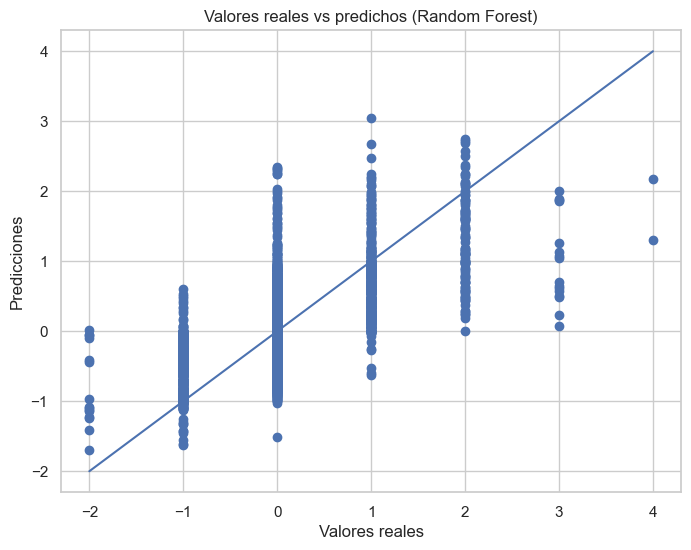

In [67]:
# Crear gráfica para comparar valores reales vs predichos
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos (Random Forest)
plt.scatter(y_test, y_pred_rf)

# Línea diagonal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Títulos
plt.title("Valores reales vs predichos (Random Forest)")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.show()